<a href="https://colab.research.google.com/github/preesr/quantum-computing/blob/main/Quantum_Circuit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit # Need this to build quantum programs, define qubits, and perform operations
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager # for optimizing the hardware

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService #ibm runtime service in IBM cloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5

In [ ]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.13
qiskit: 2.5.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.49.0


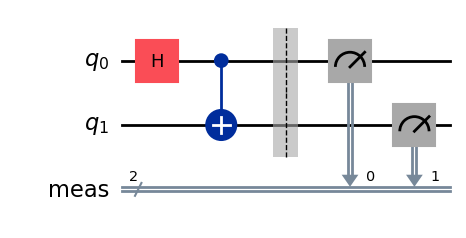

In [ ]:
# --- Build the Bell circuit (phi-plus). O/P: Phi-plus state ---
bell = QuantumCircuit(2) # instantiate QuantumCircuit
bell.h(0) # Create superposition with Hadamard gate
bell.cx(0, 1) # Add a CNOT gate to create entanglement
bell.measure_all()  # creates a classical register named "meas"

bell.draw("mpl") # render the diagram

In [ ]:

# --- Define the helper function ---#
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    """
    Transpiles the circuit for the specific backend;
    Rewrites the circuit for the hardware understand and to run efficiently
    Returns an isa_circuit
    """
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots) # submit the job; Runs the circuit multiple times
    result = job.result()

    return result[0].data.meas.get_counts() # dictionary - how often each outcome occured across all shots

In [ ]:
# Syntax for first saving your token.  Delete these lines after saving your credentials.
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="<my quantum API token>",
    overwrite=True,
    set_as_default=True,
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
# Min 127 qubits.
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-08-13 21:34:30,329: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.__init__:WARNING:2026-08-13 21:34:31,684: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default insta

ibm_marrakesh


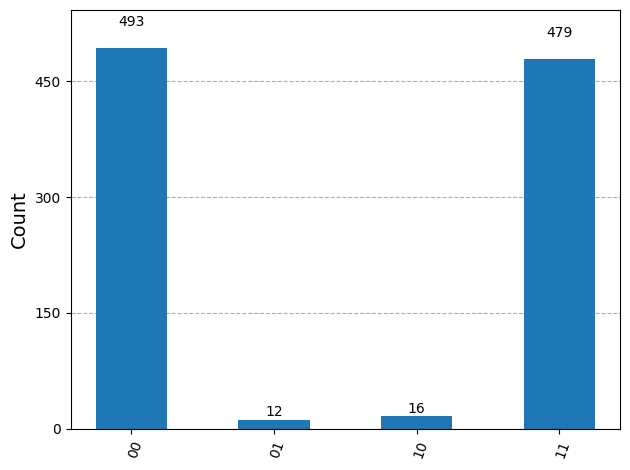

In [ ]:
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

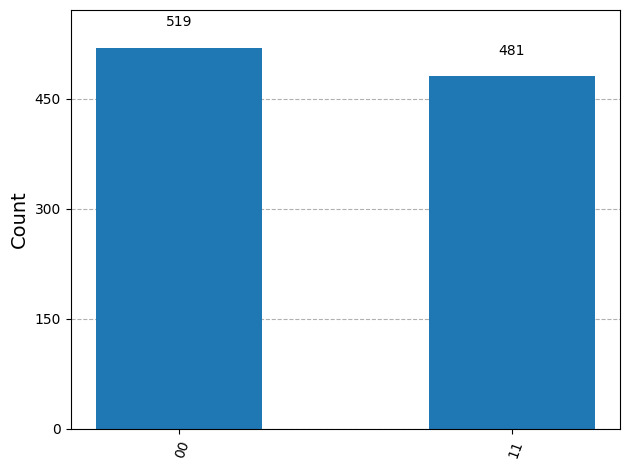

In [ ]:
##--- The above with AER simulator ---
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)

plot_histogram(counts)